# DATOS

“El dataset base proviene de Make Music Equal (licencia CC BY-SA 4.0).
Este fue enriquecido con datos obtenidos mediante la API de Chartmetric, los cuales poseen restricciones de uso.
Por este motivo, las variables derivadas de dicha fuente fueron transformadas y agregadas de forma tal que no permiten reconstruir los valores originales.”

PASO 1: Base de artistas para obtener IDs antes de conectar a la API
Fuente: Make Music Equal (CC BY-SA 4.0)
La base de datos de artistas se descargó del dataset de acceso público MakeMusicEqual versión 3/3/2026: 936420, 10.
https://chartmetric-public.s3.us-west-2.amazonaws.com/make-music-equal/mme_artist_info.csv 
Se eliminaron registros duplicados [nombre + url de artista]: 172
Resultado: 936248 filas/artistas. 
Legal: This work is licensed under a Creative Commons Attribution-ShareAlike 4.0 International License.

PASO 2: Construcción de las cohortes de datos a extraer
Base de datos MakeMusicEqual ordenada por Chartmetric_rank (rank 1 a 936248)
-cohorte 1: 1400 registros 
-cohorte 2: 600 registros 

Notas:
Hay discontinuidades en el atributo Chartmetric_rank (faltan números en la secuencia) porque la base makemusicequal está actualizada al 3/3/26 aunque fueron descargados el 23/3/2026. Misma fecha de acceso a la API. Como la variable chartmetrick_rank es dinámica, esa diferencia de 20 días hace que un artista pueda tener rank = 5 el 3/3/2026 y rank = 9 el 23/3/26. Sin embargo, eso no invalida la selección del conjunto de artistas sobre la cual se construye la extracción de datos porque el objetivo fue definir un conjunto de artistas ordenados por popularidad (medida por una fuenta de datos confiable). Además la variable rank no será utilizada en el análisis. Y por último, se comprueba que el rank puede variar sutilmente pero el conjunto de artistas definidos es predominantemente coincidente. 

PASO 3: API. Extracción de datos
Límite 14 días, 100 request x día.
Se apunta a dos endpoints: artist metadaga y artist live events
La extracción de datos se fragmenta por cohortes.


In [15]:
# !pip install pandas numpy matplotlib seaborn scikit-learn jupyter
# !pip install matplotlib
#import sys
#!{sys.executable} -m pip install matplotlib seaborn

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
import os
os.listdir()

['chartmetric definición variables.txt',
 'Chartmetric Year in Music 2024.html',
 'chartmetric_api.ipynb',
 'chartmetric_api_test.ipynb',
 'chartmetric_dataset.ipynb',
 'chartmetric_dataset_cohorte2.ipynb',
 'chartmetric_EDA1.ipynb',
 'chartmetric_liveevents_2024_2025',
 'chartmetric_liveevents_2024_2025_cohorte2',
 'chartmetric_metadata',
 'chartmetric_metadata_cohorte2',
 'cohorte1_raw_1400 - backup.csv',
 'cohorte1_raw_1400.csv',
 'cohorte2_raw_1500.csv',
 'dataset_2903.csv',
 'df_1400_api.txt',
 'df_1401_7000_api.txt',
 'jambase_api.ipynb',
 'jambase_api_key.txt',
 'jambase_extract_test',
 'Make Music Equal Report.mhtml',
 'make_music_equal_dataset.ipynb',
 'mme preguntas.txt',
 'mme_artist_info_DATASET.csv',
 'mme_head.csv',
 'mme_head_txt.txt',
 'papers',
 'raw_consolidado_2900.csv',
 'sin_shows_top_career.csv']

# levanto dataset

In [18]:
df = pd.read_csv("mme_artist_info_DATASET.csv")
# df = pd.read_csv("mme_artist_info.csv", low_memory=False)

C:\Users\Silvana\AppData\Local\Temp\ipykernel_8968\2302022066.py:1: DtypeWarning: Columns (0: chartmetric_rank) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("mme_artist_info_DATASET.csv")


In [19]:
df.columns

Index(['chartmetric_rank', 'chartmetric_id', 'artist_name', 'chartmetric_url',
       'country_name', 'composition', 'career_stage', 'pronouns', 'genre',
       'data_date'],
      dtype='str')

In [20]:
df.shape

(936420, 10)

In [21]:
df.head()

,chartmetric_rank,chartmetric_id,artist_name,chartmetric_url,country_name,composition,career_stage,pronouns,genre,data_date
0,1,214945,Bad Bunny,https://app.chartmetric.com/artist/214945,Puerto Rico,solo,superstar,he/him,reggaeton,2026-03-03
1,2,2762,Taylor Swift,https://app.chartmetric.com/artist/2762,United States,solo,superstar,she/her,pop,2026-03-03
2,3,3501,Bruno Mars,https://app.chartmetric.com/artist/3501,United States,solo,superstar,he/him,pop,2026-03-03
3,4,3479,Justin Bieber,https://app.chartmetric.com/artist/3479,Canada,solo,superstar,he/him,pop,2026-03-03
4,5,3852,The Weeknd,https://app.chartmetric.com/artist/3852,Canada,solo,superstar,he/him,r&b/soul,2026-03-03


In [22]:
df["composition"].unique()


<StringArray>
['solo', 'group', 'unknown']
Length: 3, dtype: str

In [23]:


df["career_stage"].value_counts()


career_stage
undiscovered    766574
developing      136101
mid-level        18664
mainstream       12828
superstar         1880
legendary          369
Name: count, dtype: int64

# busco un rank 186 modificado

In [24]:
import requests

REFRESH_TOKEN = "112E1dROGObsUx9hWKnrOxLQWrjDZ9YXwoByI9ynpN7QjtFY2Lq1E3uW7zvuIrpY"

# 1) token
r = requests.post(
    "https://api.chartmetric.com/api/token",
    json={"refreshtoken": REFRESH_TOKEN}
)
r.raise_for_status()
token = r.json()["token"]

headers = {"Authorization": f"Bearer {token}"}

# 2) pedir rank 186
url = "https://api.chartmetric.com/api/artist/cm_artist_rank/list"
params = {
    "min": 186,
    "max": 186,
    "limit": 10,
    "offset": 0
}

r = requests.get(url, headers=headers, params=params)

print("STATUS:", r.status_code)
print("TEXT:", r.text[:500])

r.raise_for_status()

data = r.json()["obj"]["data"]

if not data:
    print("No existe rank 186 en la API.")
else:
    artist = data[0]
    print("Rank:", artist.get("cpp_rank"))
    print("Chartmetric ID:", artist.get("chartmetric_artist_id"))
    print("Nombre:", artist.get("name"))

STATUS: 200
TEXT: {"obj":{"length":1,"data":[{"chartmetric_artist_id":4114519,"name":"ROSÉ","code2":"KR","genres":"acoustic, adventurous, angry, bittersweet, blue, calm, catchy, chill, cleaning, coffee, dance pop, dark, dreamy, drinking, driving, family, feel-good, fighting, focus, free, friendly, fun, futuristic, gentle, happy, heartbroken, hype, k-pop, late-night, lonely, longing, lounge, melancholic, mellow, morning, mourning, nostalgic, painful, pop, rain, raw, r&b/soul, reflective, revolution, romantic, runn
Rank: 186
Chartmetric ID: 4114519
Nombre: ROSÉ


In [25]:
import pandas as pd

CSV_PATH = r"C:\Users\Silvana\Downloads\taller tesis 1\make_music_equal\mme_artist_info_DATASET.csv"
CM_ID = 166   # reemplazá por el chartmetric_id que te devolvió la API

df = pd.read_csv(CSV_PATH)
df["chartmetric_id"] = pd.to_numeric(df["chartmetric_id"], errors="coerce")

match = df[df["chartmetric_id"] == CM_ID]

if match.empty:
    print("Ese chartmetric_id no aparece en tu base original.")
else:
    print(match[["chartmetric_rank", "chartmetric_id", "artist_name"]].to_string(index=False))

C:\Users\Silvana\AppData\Local\Temp\ipykernel_8968\1365454167.py:6: DtypeWarning: Columns (0: chartmetric_rank) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV_PATH)


chartmetric_rank  chartmetric_id        artist_name
             203             166 Christina Aguilera


# duplicados

In [26]:
import pandas as pd

# --- 1. CONFIGURACIÓN Y KEY ÚNICA SEGURA ---
# Usamos el ID porque el ID NUNCA es NaN y es la verdad absoluta de Chartmetric
df['unique_entity_key'] = df['chartmetric_id'].astype(str)

# --- 2. ANÁLISIS DE COLISIONES (Nombres iguales, diferentes URL, no son dupli) ---
# Agrupamos por nombre y contamos cuántas URLs distintas existen para ese nombre
analisis_urls = df.groupby('artist_name')['chartmetric_url'].nunique()
colisiones_identidad = analisis_urls[analisis_urls > 1]

# --- 3. IDENTIFICACIÓN DE DUPLICADOS TÉCNICOS ---
# Casos donde la combinación Nombre + URL se repite (deberían ser el mismo registro)
mask_duplicados_tecnicos = df.duplicated(subset=['unique_entity_key'], keep=False)
df_duplicados = df[mask_duplicados_tecnicos].copy()

# Separamos dentro de estos duplicados técnicos:
# A. Filas Espejo: Son copias exactas en todas las columnas
filas_espejo = df_duplicados[df_duplicados.duplicated(keep='first')]

# B. Filas Discrepantes: Mismo artista/URL pero algo cambia en las otras columnas
# Usamos keep=False para marcar todas las filas que tienen conflicto
discrepantes = df_duplicados[~df_duplicados.duplicated(subset=df.columns.difference(['unique_entity_key']), keep=False)]

# --- 4. REPORTE FINAL ---
print("=== INFORME DE CALIDAD DE DATOS ===")
print(f"1. Colisiones de nombre (mismo nombre diferente url): {len(colisiones_identidad)}")
print(f"2. Duplicados Técnicos (Mismo artista + URL): {df.duplicated('unique_entity_key').sum()}")
print(f"   -> Copias exactas (Espejos): {len(filas_espejo)}")
print(f"   -> Registros con datos contradictorios: {len(discrepantes)}")
print("-" * 35)

# Visualización de discrepancias si existen
if not discrepantes.empty:
    print("Muestra de registros con datos discrepantes (mismo artista, distintos valores):")
    print(discrepantes.sort_values(by='unique_entity_key').head(10))

=== INFORME DE CALIDAD DE DATOS ===
1. Colisiones de nombre (mismo nombre diferente url): 31943
2. Duplicados Técnicos (Mismo artista + URL): 172
   -> Copias exactas (Espejos): 172
   -> Registros con datos contradictorios: 0
-----------------------------------


In [27]:
# 1. Calculamos cuántos se van a ir
total_antes = len(df)
df_sindupli = df.drop_duplicates(keep='first').copy()
eliminados = total_antes - len(df_sindupli)

# 3. Verificación final mejorada
print(f"=== RESULTADO DE LA LIMPIEZA ===")
print(f"- Registros originales: {total_antes}")
print(f"- Espejos exactos eliminados: {eliminados}")
print(f"- Artistas con nombre NaN conservados: {df_sindupli['artist_name'].isna().sum()}")
print(f"- Tamaño final del dataset: {len(df_sindupli)} filas.")

=== RESULTADO DE LA LIMPIEZA ===
- Registros originales: 936420
- Espejos exactos eliminados: 172
- Artistas con nombre NaN conservados: 8
- Tamaño final del dataset: 936248 filas.


# emprolijo rank

hay baches. 

In [28]:
# Convertimos la columna a numérica, lo que no sea número se vuelve NaN
df_sindupli['chartmetric_rank'] = pd.to_numeric(df_sindupli['chartmetric_rank'], errors='coerce')

In [29]:
# Ordenamos de menor a mayor rank (el rank 1 arriba)
df_sindupli = df_sindupli.sort_values(by='chartmetric_rank', ascending=True).reset_index(drop=True)

In [30]:
# Buscamos qué valores NO se pudieron convertir a número
valores_no_numericos = df_sindupli[pd.to_numeric(df_sindupli['chartmetric_rank'], errors='coerce').isna()]['chartmetric_rank'].unique()

print("--- VALORES SOSPECHOSOS ENCONTRADOS ---")
if len(valores_no_numericos) > 0:
    print(f"Estos valores causaban el error: {valores_no_numericos}")
else:
    print("No se encontraron strings, el problema podría haber sido solo de tipos (int vs float).")

--- VALORES SOSPECHOSOS ENCONTRADOS ---
Estos valores causaban el error: [nan]


In [31]:
# Contamos cuántos NaN hay después de la conversión
nulos_count = df_sindupli['chartmetric_rank'].isna().sum()
total_filas = len(df_sindupli)

print(f"Total de registros: {total_filas}")
print(f"Registros sin Rank (NaN): {nulos_count}")
print(f"Porcentaje de nulos: {(nulos_count / total_filas) * 100:.2f}%")

Total de registros: 936248
Registros sin Rank (NaN): 4
Porcentaje de nulos: 0.00%


In [32]:
# Filtramos el DataFrame para mostrar solo las filas donde el rank es NaN
df_nulos = df_sindupli[df_sindupli['chartmetric_rank'].isna()]

print(f"--- DETALLE DE LOS {len(df_nulos)} REGISTROS CON VALOR NaN ---")
# Mostramos las columnas principales para que identifiques a los artistas
print(df_nulos[['artist_name', 'chartmetric_rank', 'chartmetric_id', 'chartmetric_url']])

--- DETALLE DE LOS 4 REGISTROS CON VALOR NaN ---
         artist_name  chartmetric_rank  chartmetric_id  \
936244  Jabbawockeez               NaN          573449   
936245  Jill & Julia               NaN          342683   
936246     Ammi Boyz               NaN          887992   
936247  Steeven Savy               NaN         3939422   

                                   chartmetric_url  
936244   https://app.chartmetric.com/artist/573449  
936245   https://app.chartmetric.com/artist/342683  
936246   https://app.chartmetric.com/artist/887992  
936247  https://app.chartmetric.com/artist/3939422  


## elimino 4 nan en rank

In [33]:
# 1. Contamos antes de borrar para la documentación
total_antes = len(df_sindupli)
nulos_a_borrar = df_sindupli['chartmetric_rank'].isna().sum()

# 2. Eliminamos las filas donde chartmetric_rank es NaN
df_sindupli = df_sindupli.dropna(subset=['chartmetric_rank']).copy()

# 3. Ordenamos por rank y reseteamos el índice
# Esto asegura que el registro físico 0 sea el Rank 1, el 1000 sea el 1001, etc.
df_sindupli = df_sindupli.sort_values(by='chartmetric_rank', ascending=True).reset_index(drop=True)

# 4. Verificación final
total_despues = len(df_sindupli)
print(f"Registros iniciales: {total_antes}")
print(f"Registros eliminados (NaN): {nulos_a_borrar}")
print(f"Registros finales: {total_despues}")
print(f"--- Dataset ordenado y listo para segmentación ---")

Registros iniciales: 936248
Registros eliminados (NaN): 4
Registros finales: 936244
--- Dataset ordenado y listo para segmentación ---


# consolido MMequal

In [34]:
#RESERVO MMequal sin dupli

df_mmequal_936244 = df_sindupli
print("df_mmequal_936244")
df_mmequal_936244.shape

df_mmequal_936244


(936244, 11)

# df_1400

In [35]:
import pandas as pd

# 1. Recortamos los primeros 1400 registros (Slicing de Python)
# Como df_sindupli ya está ordenado por rank y con index reseteado,
# esto nos garantiza los 1400 mejores artistas de tu lista.
df_1400 = df_sindupli.iloc[:1400].copy()

# 2. Definimos las columnas de interés para la auditoría de estratos
estratos = ['country_name', 'composition', 'career_stage', 'genre', 'pronouns']

print("--- AUDITORÍA DE VALORES ÚNICOS (BLOQUE 1-1400) ---")

for col in estratos:
    # Obtenemos los valores únicos
    uniques = df_1400[col].unique()
    # Contamos cuántos hay
    count = len(uniques)
    
    print(f"\nColumna: {col} ({count} categorías)")
    print(uniques)
    print("-" * 40)

# 3. Verificamos cuántas combinaciones únicas de estratos hay en este recorte
combinaciones = df_1400[estratos].drop_duplicates().shape[0]
print(f"\nTotal de 'perfiles' únicos (combinaciones de estratos): {combinaciones}")

# --- EXPORTACIÓN PARA LA API ---

# 4. Seleccionamos solo las columnas necesarias para tu proceso de descarga
columnas_interes = ['chartmetric_rank', 'chartmetric_id', 'artist_name', 'chartmetric_url']
df_1400_api = df_1400[columnas_interes]

# 5. Exportamos a un archivo .txt
# Usamos sep='\t' (tabulador) para evitar conflictos con comas en nombres de artistas
nombre_archivo = 'df_1400_api.txt'
df_1400_api.to_csv(nombre_archivo, sep='\t', index=False, encoding='utf-8')

print(f"\nArchivo '{nombre_archivo}' creado con éxito.")
print(f"Rango de Rank exportado: {df_1400_api['chartmetric_rank'].min()} a {df_1400_api['chartmetric_rank'].max()}")

--- AUDITORÍA DE VALORES ÚNICOS (BLOQUE 1-1400) ---

Columna: country_name (58 categorías)
<StringArray>
[                         'Puerto Rico',
                        'United States',
                               'Canada',
                             'Barbados',
                       'United Kingdom',
                             'Colombia',
                               'France',
                                'India',
                               'Sweden',
                          'South Korea',
                            'Australia',
                              'Jamaica',
                               'Mexico',
                         'South Africa',
                              'Senegal',
                                'Spain',
                          'Netherlands',
                            'Argentina',
                              'Nigeria',
                               'Norway',
                               'Brazil',
                              'Ire

# df_1401_7000

In [36]:
import pandas as pd

# 1. Recortamos del registro 1400 al 7000 (Slicing de Python)
# Esto toma las filas desde el índice 1400 hasta el 5999.
df_1401_7000 = df_sindupli.iloc[1400:7000].copy()

# 2. Definimos las columnas de interés para la auditoría de estratos
estratos = ['country_name', 'composition', 'career_stage', 'genre', 'pronouns']

print("--- AUDITORÍA DE VALORES ÚNICOS (BLOQUE 1401-7000) ---")

for col in estratos:
    # Obtenemos los valores únicos
    uniques = df_1401_7000[col].unique()
    # Contamos cuántos hay
    count = len(uniques)
    
    print(f"\nColumna: {col} ({count} categorías)")
    print(uniques)
    print("-" * 40)

# 3. Verificamos cuántas combinaciones únicas de estratos hay en este recorte
combinaciones = df_1401_7000[estratos].drop_duplicates().shape[0]
print(f"\nTotal de 'perfiles' únicos (combinaciones de estratos) en este bloque: {combinaciones}")

# --- EXPORTACIÓN PARA LA API ---

# 4. Seleccionamos solo las columnas necesarias para tu proceso de descarga
columnas_interes = ['chartmetric_rank', 'chartmetric_id', 'artist_name', 'chartmetric_url']
df_1401_7000_api = df_1401_7000[columnas_interes]

# 5. Exportamos a un archivo .txt
nombre_archivo = 'df_1401_7000_api.txt'
df_1401_7000_api.to_csv(nombre_archivo, sep='\t', index=False, encoding='utf-8')

print(f"\nArchivo '{nombre_archivo}' creado con éxito.")
print(f"Rango de Rank exportado: {df_1401_7000_api['chartmetric_rank'].min()} a {df_1401_7000_api['chartmetric_rank'].max()}")

--- AUDITORÍA DE VALORES ÚNICOS (BLOQUE 1401-7000) ---

Columna: country_name (106 categorías)
<StringArray>
[             'Brazil',       'United States',      'United Kingdom',
              'Mexico',           'Argentina',         'South Korea',
             'Jamaica',           'Australia',        'South Africa',
         'Puerto Rico',
 ...
           'Sri Lanka',               'Samoa',             'Senegal',
          'Madagascar', 'Trinidad and Tobago',               'Gabon',
              'Serbia',             'Hungary',            'Portugal',
            'Barbados']
Length: 106, dtype: str
----------------------------------------

Columna: composition (3 categorías)
<StringArray>
['solo', 'group', 'unknown']
Length: 3, dtype: str
----------------------------------------

Columna: career_stage (5 categorías)
<StringArray>
['superstar', 'legendary', 'mainstream', 'mid-level', 'developing']
Length: 5, dtype: str
----------------------------------------

Columna: genre (324 catego

In [37]:
print(f"Último ID del bloque anterior: {df_1400['chartmetric_rank'].iloc[-1]}")
print(f"Primer ID del bloque nuevo:    {df_1401_7000['chartmetric_rank'].iloc[0]}")

Último ID del bloque anterior: 1704.0
Primer ID del bloque nuevo:    1705.0


In [38]:
print("--- VERIFICACIÓN DE TRANSICIÓN ---")
print(f"BLOQUE 1400 (Última fila): ID {df_1400['chartmetric_id'].iloc[-1]} | Rank: {df_1400['chartmetric_rank'].iloc[-1]}")
print(f"BLOQUE 1401_7000 (Primera fila): ID {df_1401_7000['chartmetric_id'].iloc[0]} | Rank: {df_1401_7000['chartmetric_rank'].iloc[0]}")

# Verificamos si hay un salto grande en el ranking
salto = df_1401_7000['chartmetric_rank'].iloc[0] - df_1400['chartmetric_rank'].iloc[-1]
print(f"Distancia de ranking entre bloques: {salto}")

--- VERIFICACIÓN DE TRANSICIÓN ---
BLOQUE 1400 (Última fila): ID 3917158 | Rank: 1704.0
BLOQUE 1401_7000 (Primera fila): ID 1103173 | Rank: 1705.0
Distancia de ranking entre bloques: 1.0


# distribución career_stage

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Diccionario con tus DataFrames
dfs = {
    "MM Equal (936k)": df_mmequal_936244,
    "Top 1400": df_1400,
    "Segmento 1401-7000": df_1401_7000
}

# Ver resumen numérico rápido
for nombre, df in dfs.items():
    print(f"\n--- {nombre} ---")
    counts = df['career_stage'].value_counts(dropna=False)
    percents = df['career_stage'].value_counts(normalize=True, dropna=False) * 100
    resumen = pd.DataFrame({'Counts': counts, 'Percentage (%)': percents.round(2)})
    print(resumen)


--- MM Equal (936k) ---
              Counts  Percentage (%)
career_stage                        
undiscovered  766569           81.88
developing    136072           14.53
mid-level      18623            1.99
mainstream     12751            1.36
superstar       1860            0.20
legendary        369            0.04

--- Top 1400 ---
              Counts  Percentage (%)
career_stage                        
superstar       1141           81.50
legendary        230           16.43
mainstream        23            1.64
mid-level          3            0.21
developing         3            0.21

--- Segmento 1401-7000 ---
              Counts  Percentage (%)
career_stage                        
mainstream      4611           82.34
superstar        708           12.64
legendary        137            2.45
mid-level        100            1.79
developing        44            0.79


In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- PASO 1: CREAR EL NUEVO DATAFRAME FILTRADO ---
# Creamos 'df_mme_filtrado' a partir del original de 936k eliminando 'Undiscovered'
df_mme_filtrado = df_mmequal_936244[df_mmequal_936244['career_stage'] != 'undiscovered'].copy()

# Diccionario para iterar (incluyendo tus otros dos datasets)
# Nota: También filtramos 'Undiscovered' de los otros por si acaso existieran
dfs = {
    "MME (936k)": df_mmequal_936244,
    "MME (Sin Undiscovered)": df_mme_filtrado,
    "Segmento 1401-7000": df_1401_7000,
    "Top 1400": df_1400
    
}

# Ver resumen numérico rápido
for nombre, df in dfs.items():
    print(f"\n--- {nombre} ---")
    counts = df['career_stage'].value_counts(dropna=False)
    percents = df['career_stage'].value_counts(normalize=True, dropna=False) * 100
    resumen = pd.DataFrame({'Counts': counts, 'Percentage (%)': percents.round(2)})
    print(resumen)
    



--- MME (936k) ---
              Counts  Percentage (%)
career_stage                        
undiscovered  766569           81.88
developing    136072           14.53
mid-level      18623            1.99
mainstream     12751            1.36
superstar       1860            0.20
legendary        369            0.04

--- MME (Sin Undiscovered) ---
              Counts  Percentage (%)
career_stage                        
developing    136072           80.20
mid-level      18623           10.98
mainstream     12751            7.51
superstar       1860            1.10
legendary        369            0.22

--- Segmento 1401-7000 ---
              Counts  Percentage (%)
career_stage                        
mainstream      4611           82.34
superstar        708           12.64
legendary        137            2.45
mid-level        100            1.79
developing        44            0.79

--- Top 1400 ---
              Counts  Percentage (%)
career_stage                        
superstar     

In [77]:
import pandas as pd

# --- PASO 1: CREAR EL NUEVO DATAFRAME COMBINADO (1 a 1700) ---
# Concatenamos el Top 1400 con el segmento siguiente 
# (Asumiendo que df_1402_1700 ya existe en tu entorno)
df_7000 = pd.concat([df_1400, df_1401_7000], ignore_index=True)

# --- PASO 2: FILTRADO DE 'UNDISCOVERED' (Opcional pero recomendado para consistencia) ---
df_mme_filtrado = df_mmequal_936244[df_mmequal_936244['career_stage'] != 'undiscovered'].copy()

# --- PASO 3: DICCIONARIO ACTUALIZADO CON LOS 5 DATASETS ---
dfs = {
    "MME (936k)": df_mmequal_936244,
    "MME (Sin Undiscovered)": df_mme_filtrado,
    "Top 7000)": df_7000,  
    "Top 1400": df_1400
}

# --- PASO 4: ITERACIÓN Y RESUMEN ---
for nombre, df in dfs.items():
    print(f"\n--- {nombre} ---")
    # Calculamos frecuencias
    counts = df['career_stage'].value_counts(dropna=False)
    percents = df['career_stage'].value_counts(normalize=True, dropna=False) * 100
    
    # Armamos la tabla de resumen
    resumen = pd.DataFrame({
        'Counts': counts, 
        'Percentage (%)': percents.round(2)
    })
    
    # Ordenamos por índice (career_stage) para que la comparación visual sea fácil
    print(resumen.sort_index())


--- MME (936k) ---
              Counts  Percentage (%)
career_stage                        
developing    136072           14.53
legendary        369            0.04
mainstream     12751            1.36
mid-level      18623            1.99
superstar       1860            0.20
undiscovered  766569           81.88

--- MME (Sin Undiscovered) ---
              Counts  Percentage (%)
career_stage                        
developing    136072           80.20
legendary        369            0.22
mainstream     12751            7.51
mid-level      18623           10.98
superstar       1860            1.10

--- Top 7000) ---
              Counts  Percentage (%)
career_stage                        
developing        47            0.67
legendary        367            5.24
mainstream      4634           66.20
mid-level        103            1.47
superstar       1849           26.41

--- Top 1400 ---
              Counts  Percentage (%)
career_stage                        
developing         3   

In [74]:
# --- PASO 2: CONFIGURACIÓN VISUAL ESTRICTA ---
# Definimos colores fijos para que 'Mainstream' siempre sea del mismo color, etc.
colores_etapas = {
    'developing': '#4361ee', # Azul
    'mid-level': '#3a0ca3',  # Violeta oscuro
    'mainstream': '#7209b7', # Púrpura
    'superstar': '#f72585',  # Fucsia
    'legendary': '#ffbe0b',  # Dorado/Amarillo
    'undiscovered': '#8d99ae' # Gris (por si aparece en el Original)
}

orden_logico = ['undiscovered', 'developing', 'mid-level', 'mainstream', 'superstar', 'legendary']

In [78]:
tablas = []
for nombre, df in dfs.items():
    res = df['career_stage'].value_counts().reindex(orden_logico).fillna(0).astype(int)
    tablas.append(res.rename(nombre))

tabla_counts = pd.concat(tablas, axis=1)
print("--- CONTEO TOTAL POR CATEGORÍA ---")
print(tabla_counts)

--- CONTEO TOTAL POR CATEGORÍA ---
              MME (936k)  MME (Sin Undiscovered)  Top 7000)  Top 1400
career_stage                                                         
undiscovered      766569                       0          0         0
developing        136072                  136072         47         3
mid-level          18623                   18623        103         3
mainstream         12751                   12751       4634        23
superstar           1860                    1860       1849      1141
legendary            369                     369        367       230


IndexError: index 4 is out of bounds for axis 0 with size 4

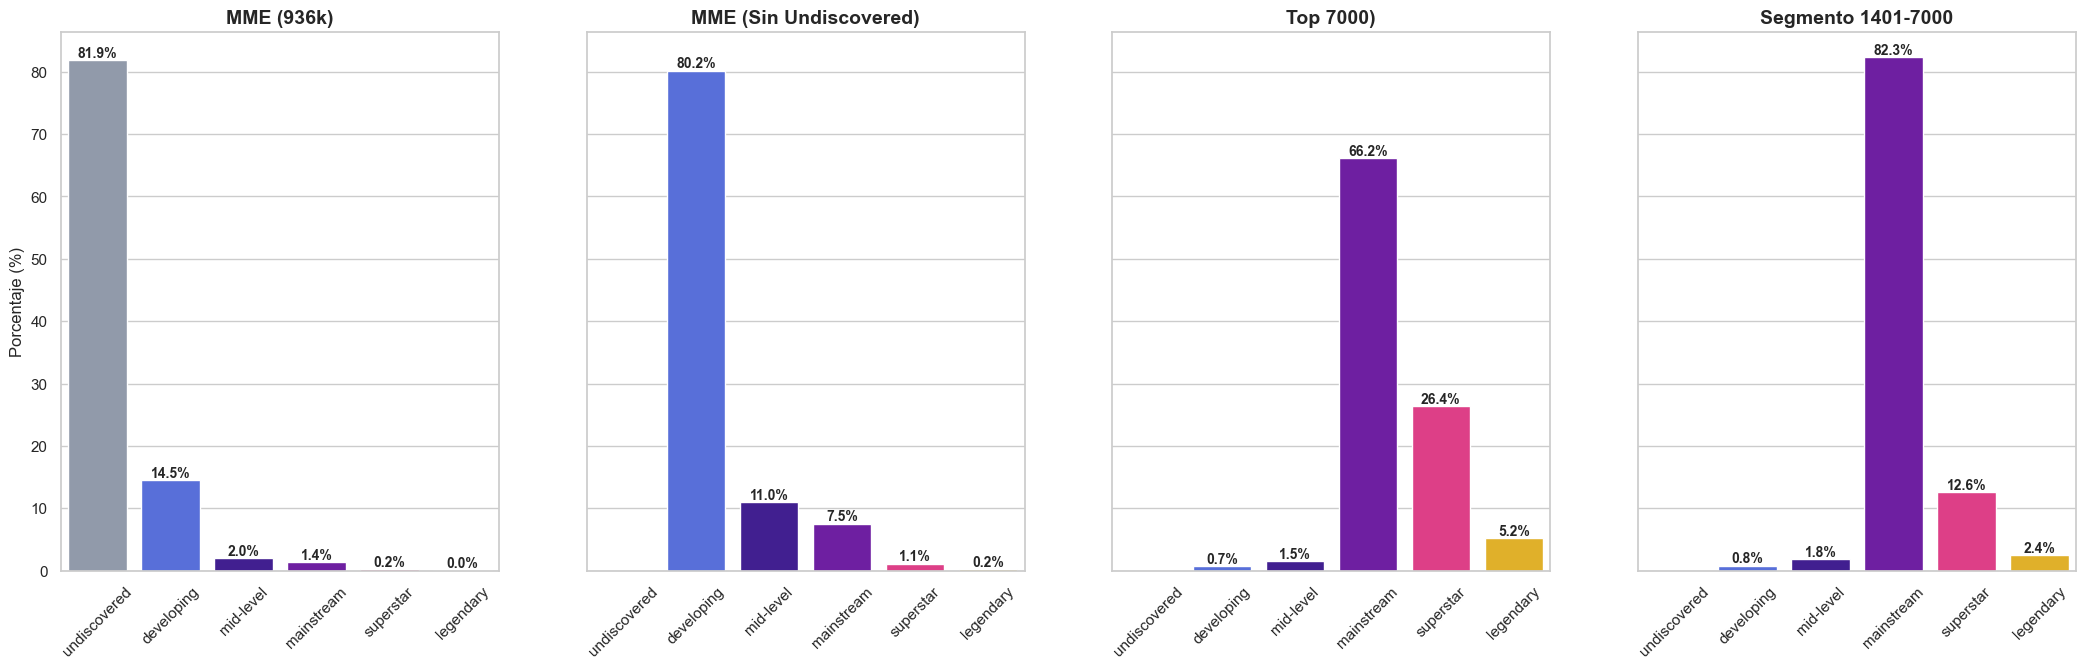

In [76]:
fig, axes = plt.subplots(1, 4, figsize=(26, 7), sharey=True)
sns.set_theme(style="whitegrid")

for i, (nombre, df) in enumerate(dfs.items()):
    # Calcular porcentajes sobre el total de CADA dataframe
    counts = df['career_stage'].value_counts(normalize=True).mul(100)
    # Reindexamos para que siempre aparezcan en el mismo orden
    data_plot = counts.reindex(orden_logico).fillna(0).reset_index()
    data_plot.columns = ['career_stage', 'percentage']
    
    # Graficar
    sns.barplot(
        data=data_plot, 
        x='career_stage', 
        y='percentage', 
        ax=axes[i], 
        palette=colores_etapas,
        hue='career_stage',
        legend=False
    )
    
    # Estética
    axes[i].set_title(nombre, fontsize=14, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Porcentaje (%)' if i == 0 else '')

    # Etiquetas de texto sobre las barras
    for p in axes[i].patches:
        h = p.get_height()
        if h > 0:
            axes[i].annotate(f'{h:.1f}%', 
                             (p.get_x() + p.get_width() / 2., h), 
                             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()